In [68]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hassanjameelahmed/olympic-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\anisa\.cache\kagglehub\datasets\hassanjameelahmed\olympic-dataset\versions\1


In [69]:
!pip install kagglehub

In [57]:
import pandas as pd

In [58]:
df = pd.read_csv("SummerSD.csv")

In [59]:
#Inspect the Dataset
df.head()
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31165 entries, 0 to 31164
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  31165 non-null  int64 
 1   Year        31165 non-null  int64 
 2   City        31165 non-null  object
 3   Sport       31165 non-null  object
 4   Discipline  31165 non-null  object
 5   Athlete     31165 non-null  object
 6   Code        31161 non-null  object
 7   Gender      31165 non-null  object
 8   Event       31165 non-null  object
 9   Medal       31165 non-null  object
 10  Country     25742 non-null  object
dtypes: int64(2), object(9)
memory usage: 2.6+ MB


(31165, 11)

In [63]:
#Remove Duplicate Rows
df = df.drop_duplicates()

In [64]:
#Inspect Missing Values
df.isnull().sum()

Unnamed: 0       0
Year             0
City             0
Sport            0
Discipline       0
Athlete          0
Code             4
Gender           0
Event            0
Medal            0
Country       5423
dtype: int64

In [61]:
df['Medal'] = df['Medal'].fillna('None')

In [65]:
# Clean Column Names
df.columns = df.columns.str.strip().str.lower()

In [70]:
df["gender"].value_counts()

gender
Men      22746
Women     8419
Name: count, dtype: int64

In [71]:
df = df.drop_duplicates()

In [73]:
#Make sure Gender is labeled 
df["gender"].unique()

array(['Men', 'Women'], dtype=object)

In [75]:
#Filter for Women Only
women_df = df[df["gender"] == "Women"]

In [76]:
#Verify it worked
women_df["gender"].unique()

array(['Women'], dtype=object)

In [79]:
# Remove Unncessary Columns
women_df = women_df[["year", "sport", "event", "medal"]]

In [51]:
#Checking for missing values
women_df.isnull().sum()

Year     0
Sport    0
Event    0
Medal    0
dtype: int64

In [80]:
#Save the Cleaned Dataset
women_df.to_csv("Women_Olympics.csv", index=False)

In [81]:
#Inspect the Dataset
df.head()
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31165 entries, 0 to 31164
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   unnamed: 0  31165 non-null  int64 
 1   year        31165 non-null  int64 
 2   city        31165 non-null  object
 3   sport       31165 non-null  object
 4   discipline  31165 non-null  object
 5   athlete     31165 non-null  object
 6   code        31161 non-null  object
 7   gender      31165 non-null  object
 8   event       31165 non-null  object
 9   medal       31165 non-null  object
 10  country     25742 non-null  object
dtypes: int64(2), object(9)
memory usage: 2.6+ MB


(31165, 11)

In [82]:
import matplotlib.pyplot as plt

In [83]:
medals_by_year = df.groupby("year")["medal"].count()

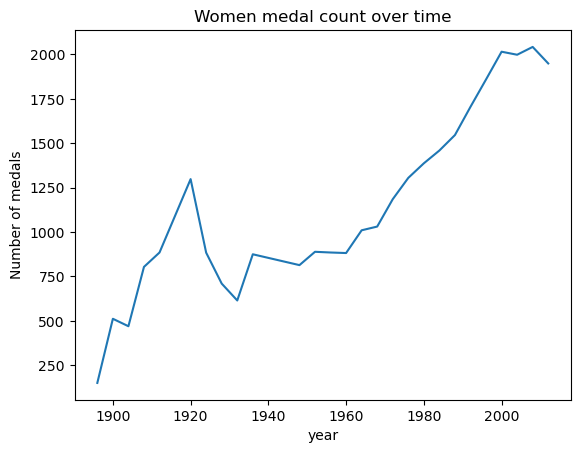

In [101]:
plt.figure()
medals_by_year.plot()
plt.xlabel("year")
plt.ylabel("Number of medals")
plt.title("Women medal count over time")
plt.show()

In [86]:
#Why is this good? Shows progress over decades, strong storytelling visual, easy to interpret.

In [102]:
import matplotlib.pyplot as plt

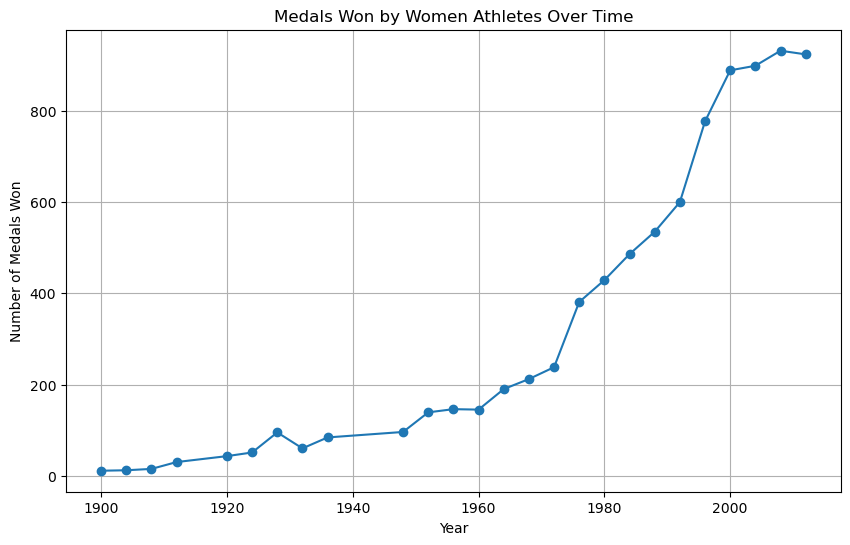

In [103]:
# Group by year and count medals won
medals_by_year = women_df.groupby('year')['medal'].count()
plt.figure(figsize=(10,6)) 
plt.plot(medals_by_year.index, medals_by_year.values, marker='o') 
plt.title("Medals Won by Women Athletes Over Time") 
plt.xlabel("Year") 
plt.ylabel("Number of Medals Won") 
plt.grid(True) 
plt.show()